In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report

from imblearn.over_sampling import ADASYN

import xgboost as xgb
import lightgbm as lgb

In [20]:
# Load dataset (adjust path if needed)
data = pd.read_csv("US_Accidents_March23.csv", nrows=160000)

print("Dataset Shape:", data.shape)

data.head()

Dataset Shape: (160000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [21]:
drop_cols = [
    "ID","Source","Start_Time","End_Time",
    "End_Lat","End_Lng","Description"
]

data = data.drop(columns=drop_cols, errors="ignore")

print("After dropping columns:", data.shape)

After dropping columns: (160000, 39)


In [22]:
# Forward fill
data = data.ffill()

# If still NaN replace with 0
data = data.fillna(0)

print("Remaining missing values:", data.isna().sum().sum())

Remaining missing values: 0


In [23]:
le = LabelEncoder()

for col in data.select_dtypes(include="object").columns:
    data[col] = le.fit_transform(data[col].astype(str))

print("Encoding complete")

Encoding complete


In [24]:
X = data.drop("Severity", axis=1)
y = data["Severity"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (160000, 38)
Target: (160000,)


In [25]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=20)

X_selected = selector.fit_transform(X, y)

print("Selected Features Shape:", X_selected.shape)

Selected Features Shape: (160000, 20)


C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 8 33] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (128000, 20)
Test shape: (32000, 20)


In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
adasyn = ADASYN(random_state=42)

X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)

print("After ADASYN:", X_resampled.shape)


After ADASYN: (287432, 20)


In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_resampled, y_resampled)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.902375


In [30]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)
y = y - 1
# Convert severity classes to start from 0
y = data["Severity"] - 1

print("Unique classes:", np.unique(y))

print("Unique classes after fix:", np.unique(y))
print("Encoded classes:", np.unique(y))

Unique classes: [0 1 2 3]
Unique classes after fix: [0 1 2 3]
Encoded classes: [0 1 2 3]


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
adasyn = ADASYN(random_state=42)

X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)

print("Resampled classes:", np.unique(y_resampled))

Resampled classes: [0 1 2 3]


In [33]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    learning_rate=0.1,
    eval_metric="mlogloss"
)

xgb_model.fit(X_resampled, y_resampled)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))


XGBoost Accuracy: 0.92871875


In [34]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

lgb_model.fit(X_resampled, y_resampled)

lgb_pred = lgb_model.predict(X_test)

print("LightGBM Accuracy:",
      accuracy_score(y_test, lgb_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020339 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5096
[LightGBM] [Info] Number of data points in the train set: 293083, number of used features: 20
[LightGBM] [Info] Start training from score -1.403179
[LightGBM] [Info] Start training from score -1.403804
[LightGBM] [Info] Start training from score -1.336118
[LightGBM] [Info] Start training from score -1.403804


C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.9201875


In [35]:
hybrid_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],
    voting='soft'
)

hybrid_model.fit(X_resampled, y_resampled)

hybrid_pred = hybrid_model.predict(X_test)

print("Hybrid Model Accuracy:",
      accuracy_score(y_test, hybrid_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5096
[LightGBM] [Info] Number of data points in the train set: 293083, number of used features: 20
[LightGBM] [Info] Start training from score -1.403179
[LightGBM] [Info] Start training from score -1.403804
[LightGBM] [Info] Start training from score -1.336118
[LightGBM] [Info] Start training from score -1.403804


C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Hybrid Model Accuracy: 0.92565625


In [37]:
print("\nHybrid Model Report\n")

print(classification_report(y_test, hybrid_pred))


Hybrid Model Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.94      0.93      0.94     17912
           2       0.91      0.92      0.92     14049
           3       0.05      0.14      0.07        22

    accuracy                           0.93     32000
   macro avg       0.48      0.50      0.48     32000
weighted avg       0.93      0.93      0.93     32000



In [53]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
import lightgbm as lgb


# ==============================
# Improved XGBoost Model
# ==============================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42
)
xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)


# ==============================
# Improved LightGBM Model
# ==============================

lgb_model = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


# ==============================
# Hybrid Ensemble Model
# ==============================

hybrid_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],
    voting='soft',
    weights=[2,2]
)

# Train model
hybrid_model.fit(X_resampled, y_resampled)

# Prediction
hybrid_pred = hybrid_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, hybrid_pred)

print("Improved Hybrid Model Accuracy:", accuracy)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017483 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5096
[LightGBM] [Info] Number of data points in the train set: 287996, number of used features: 20
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Improved Hybrid Model Accuracy: 0.93896875


In [54]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    hybrid_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1886
[LightGBM] [Info] Number of data points in the train set: 102400, number of used features: 20
[LightGBM] [Info] Start training from score -7.004042
[LightGBM] [Info] Start training from score -0.575382
[LightGBM] [Info] Start training from score -0.830346
[LightGBM] [Info] Start training from score -7.259976
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1887
[LightGBM] [Info] Number of data points in the train set: 102400, number of used features: 20
[LightGBM] [Info] Start training from score -6.993347
[LightGBM] [Info] Start training from score -0.575382
[LightGBM] [Info] Start training from score -0.830346
[LightGBM] [Info] Start training from score -7.273962
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1887
[LightGBM] [Info] Number of data points in the train set: 102400, number of used features: 20
[LightGBM] [Info] Start training from score -6.993347
[LightGBM] [Info] Start training from score -0.575382
[LightGBM] [Info] Start training from score -0.830346
[LightGBM] [Info] Start training from score -7.273962
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1888
[LightGBM] [Info] Number of data points in the train set: 102400, number of used features: 20
[LightGBM] [Info] Start training from score -6.993347
[LightGBM] [Info] Start training from score -0.575382
[LightGBM] [Info] Start training from score -0.830346
[LightGBM] [Info] Start training from score -7.273962


C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005723 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1889
[LightGBM] [Info] Number of data points in the train set: 102400, number of used features: 20
[LightGBM] [Info] Start training from score -7.004042
[LightGBM] [Info] Start training from score -0.575364
[LightGBM] [Info] Start training from score -0.830346
[LightGBM] [Info] Start training from score -7.273962


C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Cross Validation Scores: [0.9425     0.94109375 0.94050781 0.94195312 0.94296875]
Mean Accuracy: 0.9418046875


In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

pred = hybrid_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, average='weighted'))
print("Recall:", recall_score(y_test, pred, average='weighted'))
print("F1 Score:", f1_score(y_test, pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.93896875
Precision: 0.9391954279282198
Recall: 0.93896875
F1 Score: 0.9390657795338068

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.95      0.94      0.95     17912
           2       0.93      0.93      0.93     14049
           3       0.07      0.14      0.09        22

    accuracy                           0.94     32000
   macro avg       0.49      0.50      0.49     32000
weighted avg       0.94      0.94      0.94     32000



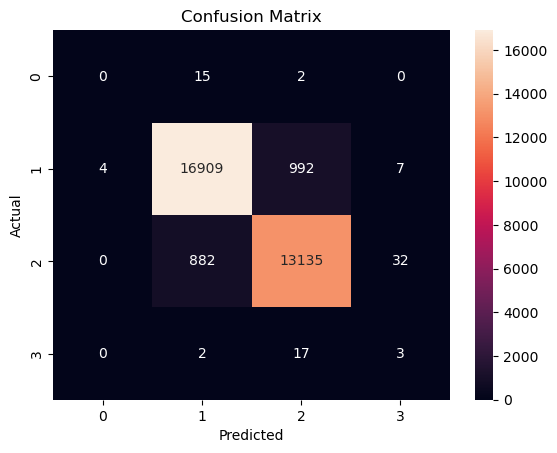

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [57]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

param_grid = {
    'max_depth':[6,8,10],
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':[100,200,300]
}

grid = GridSearchCV(
    xgb.XGBClassifier(eval_metric="mlogloss"),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300}
Best Accuracy: 0.9405859409717783


In [58]:
best_xgb = grid.best_estimator_

best_xgb.fit(X_train, y_train)

pred = best_xgb.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, pred))

Final Accuracy: 0.9450625


In [60]:
from sklearn.metrics import accuracy_score

# Predictions
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)
hybrid_pred = hybrid_model.predict(X_test)
best_xgb_pred = best_xgb.predict(X_test)

# Accuracies
rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)
lgb_acc = accuracy_score(y_test, lgb_pred)
hybrid_acc = accuracy_score(y_test, hybrid_pred)
best_xgb_acc = accuracy_score(y_test, best_xgb_pred)

# Store in dictionary for easier plotting
model_acc = {
    "Random Forest": rf_acc,
    "XGBoost": xgb_acc,
    "LightGBM": lgb_acc,
    "Hybrid": hybrid_acc,
    "Tuned XGBoost": best_xgb_acc
}

print("Model Accuracies:")
for model, acc in model_acc.items():
    print(f"{model}: {acc:.4f}")

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [61]:
# Random Forest
rf_model.fit(X_resampled, y_resampled)

# XGBoost
xgb_model.fit(X_resampled, y_resampled)

# LightGBM
lgb_model.fit(X_resampled, y_resampled)

# Hybrid Ensemble
hybrid_model.fit(X_resampled, y_resampled)

# Best XGBoost from GridSearch
best_xgb.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019561 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5096
[LightGBM] [Info] Number of data points in the train set: 287996, number of used features: 20
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016707 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5096
[LightGBM] [Info] Number of data points in the train set: 287996, number of used features: 20
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Star

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [62]:
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)
hybrid_pred = hybrid_model.predict(X_test)
best_xgb_pred = best_xgb.predict(X_test)

C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pokal\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [63]:
from sklearn.metrics import accuracy_score

model_acc = {
    "Random Forest": accuracy_score(y_test, rf_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred),
    "LightGBM": accuracy_score(y_test, lgb_pred),
    "Hybrid": accuracy_score(y_test, hybrid_pred),
    "Tuned XGBoost": accuracy_score(y_test, best_xgb_pred)
}

print(model_acc)

{'Random Forest': 0.895625, 'XGBoost': 0.94034375, 'LightGBM': 0.9340625, 'Hybrid': 0.93896875, 'Tuned XGBoost': 0.9450625}


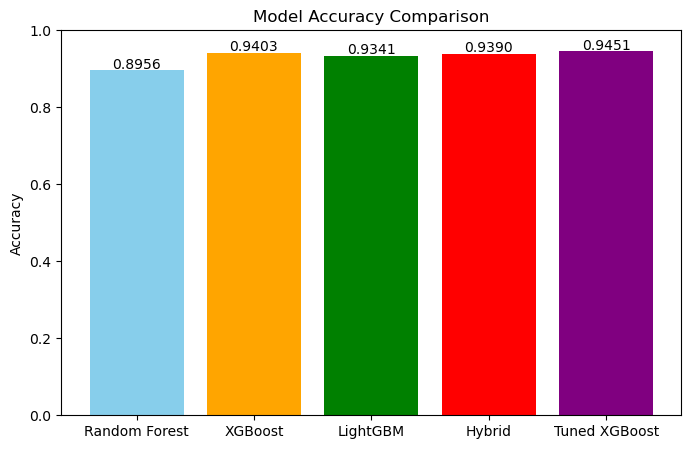

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(model_acc.keys(), model_acc.values(), color=['skyblue','orange','green','red','purple'])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
for i, v in enumerate(model_acc.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.show()